In [1]:
import labslib.gregplotlib as gpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns

from cloudpathlib import S3Path

S3_DATA_DIR = S3Path("s3://drivendata-competition-depth-estimation/data")

%matplotlib inline

In [2]:
# load private labels
labels = pd.read_csv(S3_DATA_DIR / "final/private/test_labels.csv")
labels.head()

,video_id,time,distance
0,aaju.mp4,0,1.0
1,aava.mp4,30,2.0
2,aava.mp4,40,2.0
3,aava.mp4,50,3.0
4,abhg.mp4,2,3.0


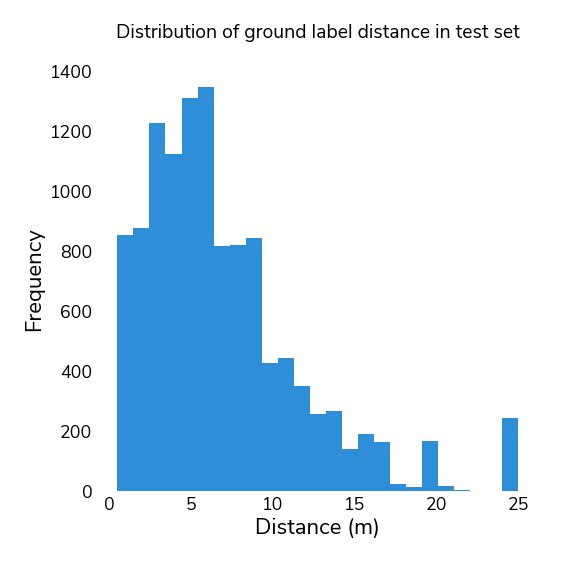

In [3]:
with gpl.styled_fig_ax(size="square", ) as ax:
    plt.hist(labels.distance, bins=25)
    plt.title("Distribution of ground label distance in test set\n", fontsize=14)
    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    ax.figure.savefig("distance_ground_truth.png", dpi=300)

In [4]:
(labels.distance <= 5).mean()

np.float64(0.451642641635937)

In [5]:
(labels.distance <= 10).mean()

np.float64(0.8080791149849145)

### Best model form second place

In [6]:
preds2nd = pd.read_csv(S3_DATA_DIR / "winners/second/sub_tf_efficientnetv2_l_in21k_2_5_pl4.csv")

# round distance like in second step of inference.sh
preds2nd["distance"] = (preds2nd.distance * 2).round() / 2

preds2nd = preds2nd.merge(
    labels,
    on=["video_id", "time"],
    how="inner",
    validate="1:1",
    suffixes=("_pred", "_gt"),
)
preds2nd["e"] = preds2nd["distance_pred"] - preds2nd["distance_gt"]
preds2nd["ae"] = np.abs(preds2nd["e"])
preds2nd.head()

,video_id,time,distance_pred,distance_gt,e,ae
0,aaju.mp4,0,2.0,1.0,1.0,1.0
1,aava.mp4,30,3.0,2.0,1.0,1.0
2,aava.mp4,40,3.5,2.0,1.5,1.5
3,aava.mp4,50,4.0,3.0,1.0,1.0
4,abhg.mp4,2,4.0,3.0,1.0,1.0


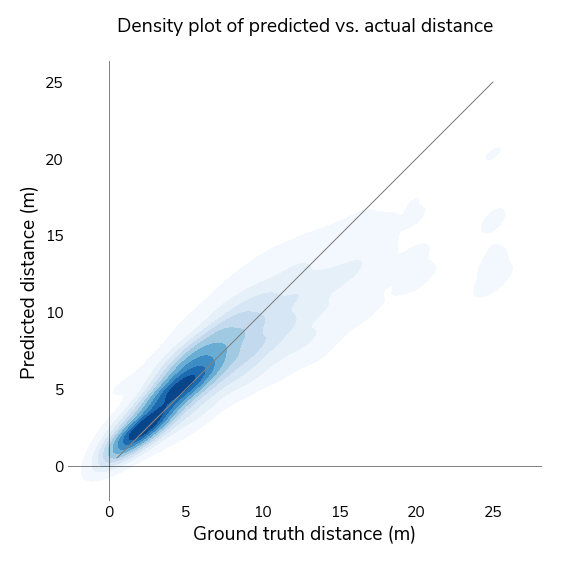

In [7]:
with gpl.styled_fig_ax(
    size="square",
    zero_lines=True,
    font_size=14
) as ax:
    sns.kdeplot(data=preds2nd, x="distance_gt", y="distance_pred", fill=True, cmap='Blues', thresh=0.05, ax=ax)

    plt.xlabel("Ground truth distance (m)")
    plt.ylabel("Predicted distance (m)")
    plt.title("Density plot of predicted vs. actual distance\n", fontsize=14)

    plt.plot(
        preds2nd.distance_gt,
        preds2nd.distance_gt,
        "-",
        color="gray",
        linewidth=0.5,
        label="Predicted = Actual",
    )

    ax.set_aspect("equal")
    plt.tight_layout()
    ax.figure.savefig("distance_density.png", dpi=300)

In [8]:
by_species = pd.read_csv(S3_DATA_DIR / "interim/all_labels_split.csv")
by_species = by_species.merge(
    preds2nd, how="inner", on=["video_id", "time"], validate="1:1"
)

In [9]:
by_species.species.value_counts()

species
duiker        5718
bushbuck      2603
chimpanzee    2150
monkey        1279
leopard        162
elephant        20
Name: count, dtype: int64

In [10]:
sp_labels = {
    sp: f"{sp.title()} ({by_species.species.value_counts()[sp]})"
    for sp in by_species.species.unique()
}

by_species["species_with_counts"] = by_species.species.map(sp_labels)
order = ["monkey", "chimpanzee", "bushbuck", "duiker", "leopard", "elephant"]
order_labels = [sp_labels[o] for o in order]

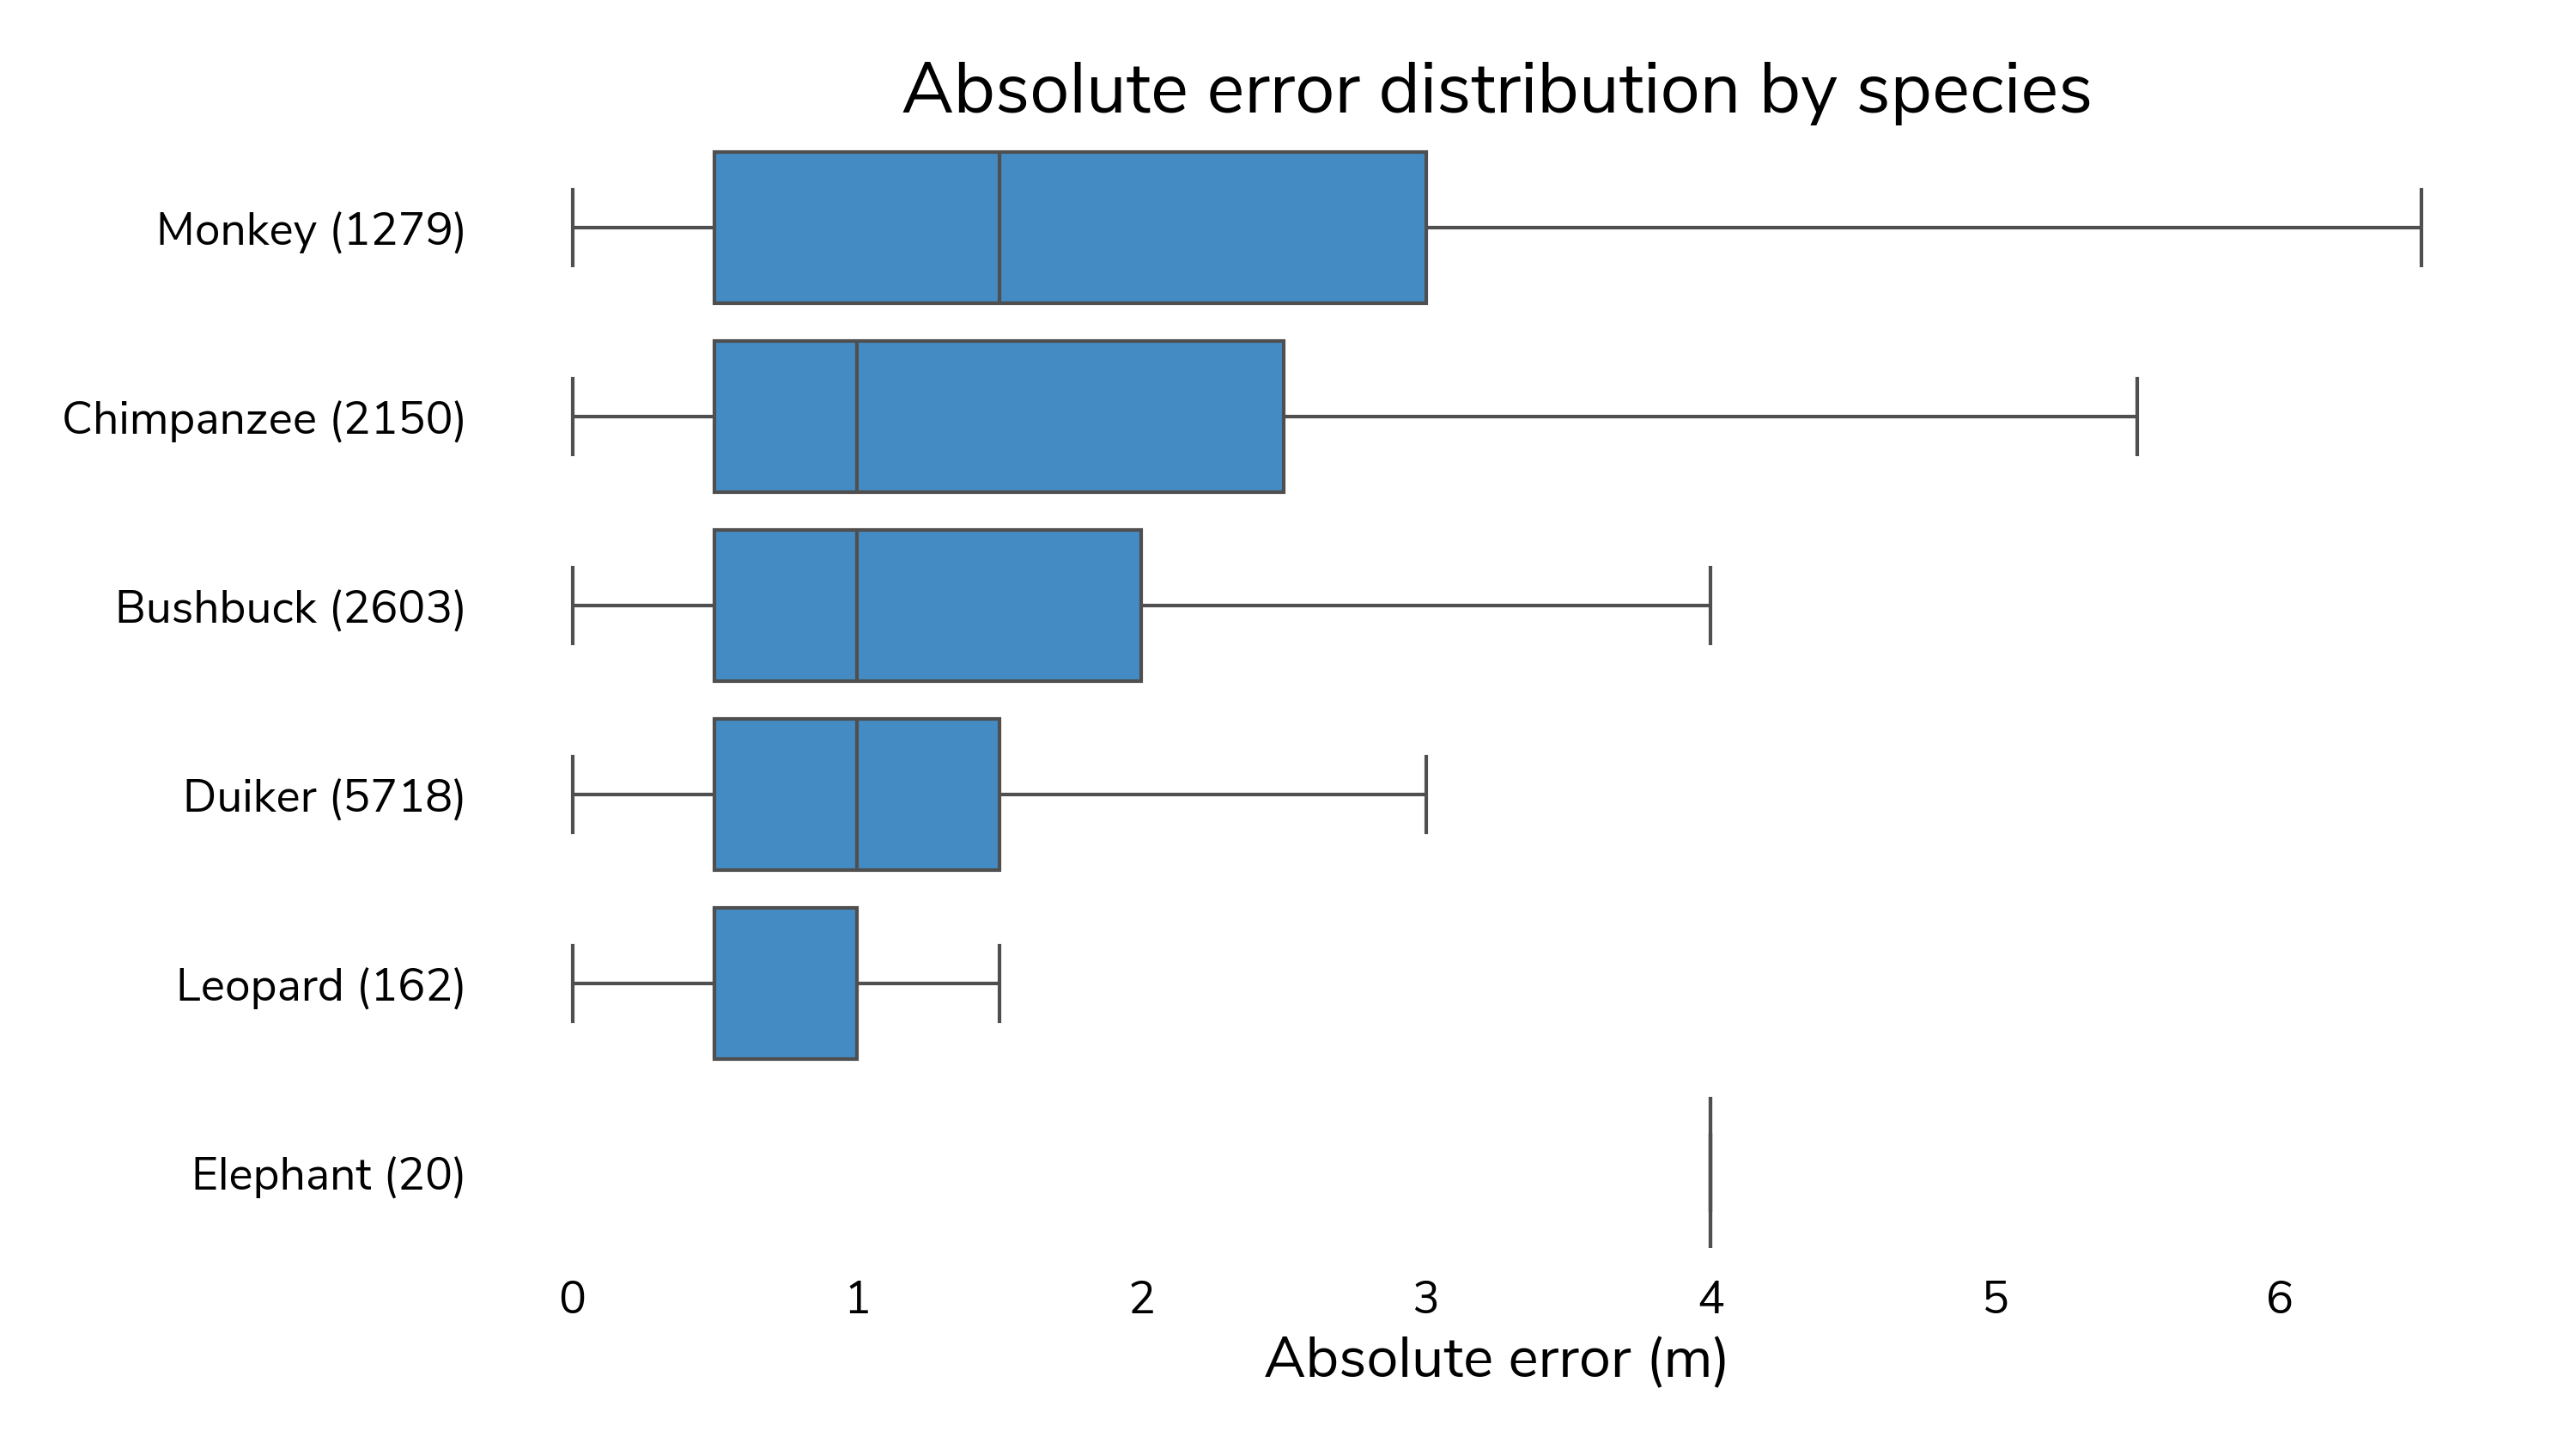

In [11]:
with gpl.styled_fig_ax(size="full", presentation_dpi=300) as ax:
    sns.boxplot(data=by_species, x="ae", y="species_with_counts", showfliers=False, order=order_labels)
    plt.ylabel("")
    plt.xlabel("Absolute error (m)")
    plt.xticks()
    ax.set_title("Absolute error distribution by species")
    plt.tight_layout()
    ax.figure.savefig("distance_species_error.png", dpi=300)